# Fashion_MNIST

In [2]:
import numpy as np  # Importa la librería NumPy con el alias 'np', utilizada para operaciones matemáticas y manejo eficiente de arreglos (arrays) y matrices.
import keras  # Importa la librería Keras, un framework de alto nivel para construir y entrenar redes neuronales.
from keras import layers  # Importa el submódulo 'layers' de Keras, necesario para definir capas de redes neuronales (Dense, Conv2D, LSTM, etc.).
import matplotlib.pyplot as plt  # Importa la librería Matplotlib con el alias 'plt', utilizada para crear gráficos y visualizaciones de datos.
import warnings  # Importa el módulo 'warnings', que permite controlar y suprimir advertencias en el código.
warnings.filterwarnings("ignore")  # Configura Python para ignorar todas las advertencias y no mostrarlas en la salida.
import math  # Importa la librería matemática estándar de Python, útil para funciones como sqrt, sin, cos, etc.
import pandas as pd  # Importa la librería Pandas con el alias 'pd', usada para manipulación y análisis de datos mediante DataFrames.
import os  # Importa el módulo 'os', que permite interactuar con el sistema operativo (rutas, variables de entorno, archivos, etc.).

# Configurar TensorFlow para ignorar ciertos mensajes de información y advertencia
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # '0'=mostrar todo, '1'=información, '2'=advertencias, '3'=errores solamente

from tensorflow import keras  # Importa Keras desde TensorFlow, versión integrada y más compatible con TF 2.x
from tensorflow.keras import layers  # Importa el submódulo 'layers' de Keras dentro de TensorFlow

import random  # Importa el módulo 'random' de Python, utilizado para generar números aleatorios y realizar operaciones aleatorias

# Establecer una semilla global para reproducibilidad
seed = 13  # Definimos un valor fijo para la semilla
np.random.seed(seed)  # Semilla para NumPy, asegura que los números aleatorios generados por NumPy sean reproducibles
random.seed(seed)  # Semilla para el módulo random de Python
keras.utils.set_random_seed(seed)  # Semilla para Keras/TensorFlow, asegura reproducibilidad de inicialización de pesos y operaciones aleatorias

Definamos los tamaños de fuente predeterminados para que las figuras se vean mejor:

In [4]:
# Configura el tamaño de fuente general por defecto en los gráficos
plt.rc('font', size=14)

# Configura el tamaño de las etiquetas de los ejes (x, y) y el tamaño del título del gráfico
plt.rc('axes', labelsize=14, titlesize=14)

# Configura el tamaño de la fuente de la leyenda del gráfico
plt.rc('legend', fontsize=14)

# Configura el tamaño de las etiquetas en el eje x (números o categorías)
plt.rc('xtick', labelsize=10)

# Configura el tamaño de las etiquetas en el eje y (números o categorías)
plt.rc('ytick', labelsize=10)

## Funciones

In [6]:
from pathlib import Path  # Importa la clase Path para manejar rutas de archivos y carpetas de forma segura

# Crea la ruta donde se guardarán las imágenes: ./images/ann
IMAGES_PATH = Path() / "images" / "CNN-IPN"

# Crea la carpeta si no existe
# parents=True permite crear también carpetas intermedias
# exist_ok=True evita error si la carpeta ya existe
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Función para guardar figuras generadas con matplotlib
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):

    # Construye la ruta completa del archivo usando el nombre de la figura
    # Ejemplo: images/ann/grafica1.png
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"

    # Ajusta automáticamente los espacios del gráfico para evitar que se encimen etiquetas o títulos
    if tight_layout:
        plt.tight_layout()

    # Guarda la figura en la ruta especificada
    # format = tipo de archivo (png, jpg, pdf, etc.)
    # dpi = resolución de la imagen (300 es calidad alta para artículos o reportes)
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [7]:
def mostrar_imagen_grises(imagen, cmap="binary"):
    """
    Muestra una imagen en escala de grises.

    Parámetros:
    imagen : array-like
        Imagen a mostrar.
    cmap : str, opcional
        Mapa de color (por defecto 'binary').

    Nota:
    - Valores pequeños → blanco
    - Valores grandes → negro
    """
    plt.imshow(imagen, cmap=cmap)
    plt.axis('off')  # Oculta los ejes
    plt.show()       # Muestra la imagen

In [8]:
def mostrar_guardar_imagenes(n_rows, n_cols, x_train, y_train, nombre_guardar, titulo):
    """
    Genera una figura con una cuadrícula de imágenes, coloca títulos a cada imagen,
    agrega un título general y guarda la figura en un archivo.
    
    Parámetros:
        n_rows (int): Número de filas en la cuadrícula.
        n_cols (int): Número de columnas en la cuadrícula.
        x_train (array-like): Conjunto de imágenes a mostrar.
        y_train (array-like): Etiquetas de las imágenes.
        nombre_guardar (str): Nombre del archivo para guardar la figura.
        titulo (str): Título general de la figura.
    """
    
    plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
    
    # Título general
    plt.suptitle(titulo, fontsize=16)
    
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col
            if index >= len(x_train):
                break  # Evita errores si x_train tiene menos imágenes
            
            plt.subplot(n_rows, n_cols, index + 1)
            plt.imshow(x_train[index], cmap="binary", interpolation="nearest")
            plt.axis('off')
            plt.title(y_train[index], fontsize=8)
    
    plt.subplots_adjust(wspace=0.2, hspace=0.5, top=0.88)  # Ajusta el espacio para el título
    save_fig(nombre_guardar)  # Guarda la figura
    plt.show()  # Muestra la figura



def plot_learning_curves_clasificacion(history, nombre_imagen):
    # Convertir a DataFrame
    df = pd.DataFrame(history.history)

    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 5))

    # Graficar pérdida
    if 'loss' in df and 'val_loss' in df:
        ax.plot(df.index + 1, df['loss'], "r--", label="Train Loss")
        ax.plot(df.index + 1, df['val_loss'], "b--.", label="Val Loss")

    # Graficar accuracy (clasificación)
    if 'accuracy' in df and 'val_accuracy' in df:
        ax.plot(df.index + 1, df['accuracy'], "r-", label="Train Accuracy")
        ax.plot(df.index + 1, df['val_accuracy'], "b-*", label="Val Accuracy")

    # Configuración de ejes
    ax.set_xlim(1, len(df))
    ax.set_ylim(0, 1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Metric Value")
    ax.grid(True)

    # Leyenda fuera del gráfico
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig(nombre_imagen)
    plt.show()

## Parámetros del modelo

In [10]:
input_shape = (28, 28, 1)  # Tamaño de las imágenes (alto, ancho, canales) , estas imagpenes están en escala de grises
input_shape

(28, 28, 1)

[Fashion_MNIST](https://keras.io/api/datasets/fashion_mnist/) : Este conjunto de datos contiene $60,000$ imágenes en escala de grises de $28$x$28$ píxeles, pertenecientes a $10$ categorías de moda, junto con un conjunto de prueba de $10,000$ imágenes. Este conjunto de datos puede utilizarse como sustituto directo de MNIST.

In [12]:
fashion_mnist = keras.datasets.fashion_mnist.load_data()
fashion_mnist

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

Carga el dataset **Fashion_MNIST** y lo divide en datos de entrenamiento y prueba

Separamos los datos en entrenamiento completo y prueba (test)

$X$: imágenes

$y$: etiquetas (clases)

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [16]:
total = len(x_train) + len(x_test) # Total de muestras
# Proporciones iniciales (train vs test)
train_prop = len(x_train) / total
test_prop = len(x_test) / total
print(
f"""Proporciones originales: Total de imágenes {total}
Entrenamiento completo: {len(x_train)} ({train_prop*100:.2f}%)
Prueba:       {len(x_test)} ({test_prop*100:.2f}%)
""")

Proporciones originales: Total de imágenes 70000
Entrenamiento completo: 60000 (85.71%)
Prueba:       10000 (14.29%)



El conjunto de entrenamiento contiene $60,000$ imágenes en escala de grises, cada una de $28$x$28$ píxeles:

In [18]:
x_train.shape

(60000, 28, 28)

In [19]:
print(f"""
Valor mínimo (entrenamiento): {x_train.min()}          Valor máximo (entrenamiento): {x_train.max()} 
Valor mínimo (prueba): {x_test.min()}                  Valor máximo (prueba): {x_test.max()}""") 


Valor mínimo (entrenamiento): 0          Valor máximo (entrenamiento): 255 
Valor mínimo (prueba): 0                  Valor máximo (prueba): 255


Observemos como se ve la primer imagen del **entrenamiento**.

In [21]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

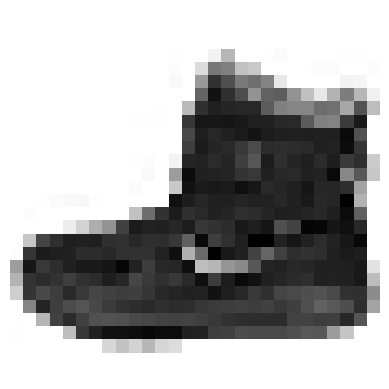

In [22]:
mostrar_imagen_grises(x_train[0], cmap="binary")

Observemos como se ve la primer imagen de **prueba**.

In [24]:
x_test[0] #Primer imagen de datos de entrenamiento

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

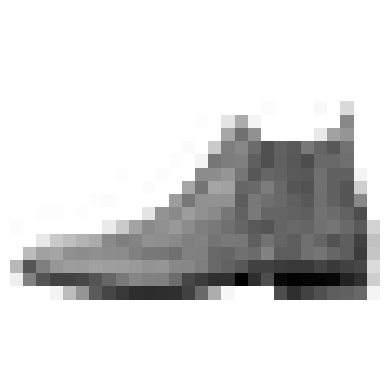

In [25]:
mostrar_imagen_grises(x_test[0], cmap="binary")

## Normalización

Total de muestras

In [28]:
total = len(x_train) + len(x_test) # Total de muestras
total

70000

Proporciones

In [30]:
# Proporciones iniciales (train_full vs test)
train_prop = len(x_train) / total
test_prop = len(x_test) / total
print(
f"""Proporciones originales: Total de imágenes {total}
Entrenamiento:  {len(x_train)} ({train_prop*100:.2f}%)
Prueba:         {len(x_test)}  ({test_prop*100:.2f}%)
""")

Proporciones originales: Total de imágenes 70000
Entrenamiento:  60000 (85.71%)
Prueba:         10000  (14.29%)



Tipo de datos

In [32]:
print(f"""Tipo de datos (entrenamiento): {x_train.dtype } 
Tipo de datos (prueba): {x_test.dtype } """ )

Tipo de datos (entrenamiento): uint8 
Tipo de datos (prueba): uint8 


- Ver el tipo de dato (byte =  <code>uint8 </code> ): Eso significa que cada píxel usa 1 byte ($8$ bits) → valores de $0$ a $255$

Valores de $0$ a $255$

- $0$ → negro absoluto (sin luz)
- $255$ → blanco total (máxima intensidad)
- Valores intermedios → tonos de gris

Vamos a reducir las intensidades de los píxeles al rango de $0$ a $1$ y convertirlas a números de tipo flotante, dividiéndolas por $255$:

In [35]:
# Normalizamos las imágenes para la CNN dividiéndolas entre 255
# - Originalmente, los píxeles están en el rango 0-255
# - Después de la normalización, quedan entre 0 y 1
# - Esto mejora la convergencia de la red convolucional y evita saturación de activaciones
x_train,  x_test = x_train / 255. , x_test / 255.

**Probamos las primeras imágenes después del escalado**

Entrenamiento

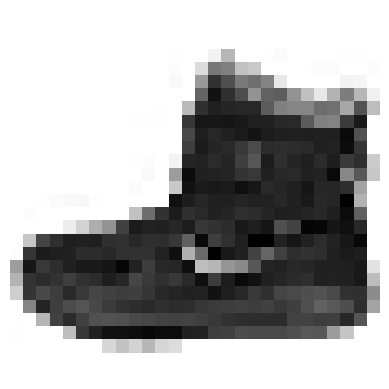

In [37]:
mostrar_imagen_grises(x_train[0], cmap="binary")

Prueba

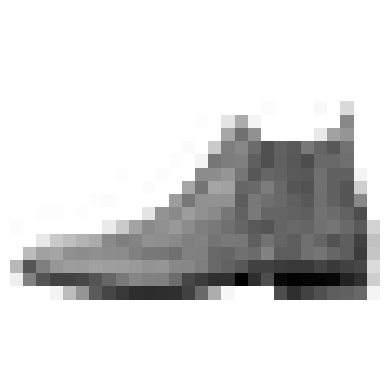

In [39]:
mostrar_imagen_grises(x_test[0], cmap="binary")

**Revisamos el tipo de valor de la variable objetivo**

In [41]:
print(f""" 
Valores únivos y (entrenamiento): {np.unique(y_train)}       registros:{y_train.shape[0]}
Valores únicos y (prueba): {np.unique(y_test)}              registros:{y_test.shape[0]}
""")

 
Valores únivos y (entrenamiento): [0 1 2 3 4 5 6 7 8 9]       registros:60000
Valores únicos y (prueba): [0 1 2 3 4 5 6 7 8 9]              registros:10000



In [42]:
num_classes = len(np.unique(y_train))  # Número de clases (dígitos del 0 al 9)
num_classes

10

Lista de nombres de las clases del dataset **Fashion MNIST**
- Cada posición del arreglo corresponde a una etiqueta numérica (0 a 9)


In [44]:
class_names = [
    "T-shirt/top",  # 0 → camiseta o top
    "Trouser",      # 1 → pantalón
    "Pullover",     # 2 → suéter
    "Dress",        # 3 → vestido
    "Coat",         # 4 → abrigo
    "Sandal",       # 5 → sandalia
    "Shirt",        # 6 → camisa
    "Sneaker",      # 7 → tenis (zapato deportivo)
    "Bag",          # 8 → bolsa
    "Ankle boot"    # 9 → botín
]

Observamos los primeros $10$ valores objetivos del conjunto de entrenamiento

In [46]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

Que con sus valores, sería.

In [48]:
[class_names[i] for i in y_train[:10]]

['Ankle boot',
 'T-shirt/top',
 'T-shirt/top',
 'Dress',
 'T-shirt/top',
 'Pullover',
 'Sneaker',
 'Pullover',
 'Sandal',
 'Sandal']

**Ejemplo: Convertir etiquetas dispersas en etiquetas vectoriales one-hot**, utilizando la función  <code> tf.keras.utils.to_categorical </code> 

In [50]:
# Ejemplo: tenemos 4 etiquetas de clase como enteros
y_int = [0, 5, 1, 0]

# Convertimos a one-hot vectors con 10 clases
y_one_hot = keras.utils.to_categorical(y_int, num_classes=10)

y_one_hot

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

**Ejemplo: Convertir de etiquetas vectoriales a etiquetas dispersas**

In [52]:
y_dispersa = np.argmax(y_one_hot, axis= 1)
y_dispersa

array([0, 5, 1, 0], dtype=int64)

Tenemos que las columnas <code> y_train </code>  y <code> y_test </code> son columnas disperas, por lo cual, las convertiremos en etiquetas vectoriales.

In [54]:
# Convierte las etiquetas de clase (y_train, y_test) a formato one-hot.
# Esto es necesario para la mayoría de modelos de clasificación con Keras cuando se usa
# 'categorical_crossentropy' como función de pérdida.
# Por ejemplo, si num_classes=10 y una etiqueta es 3, se convierte en:
# [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes=num_classes)

Obtengo los primeros $10$ valores del entrenamiento

In [56]:
y_train[:10]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

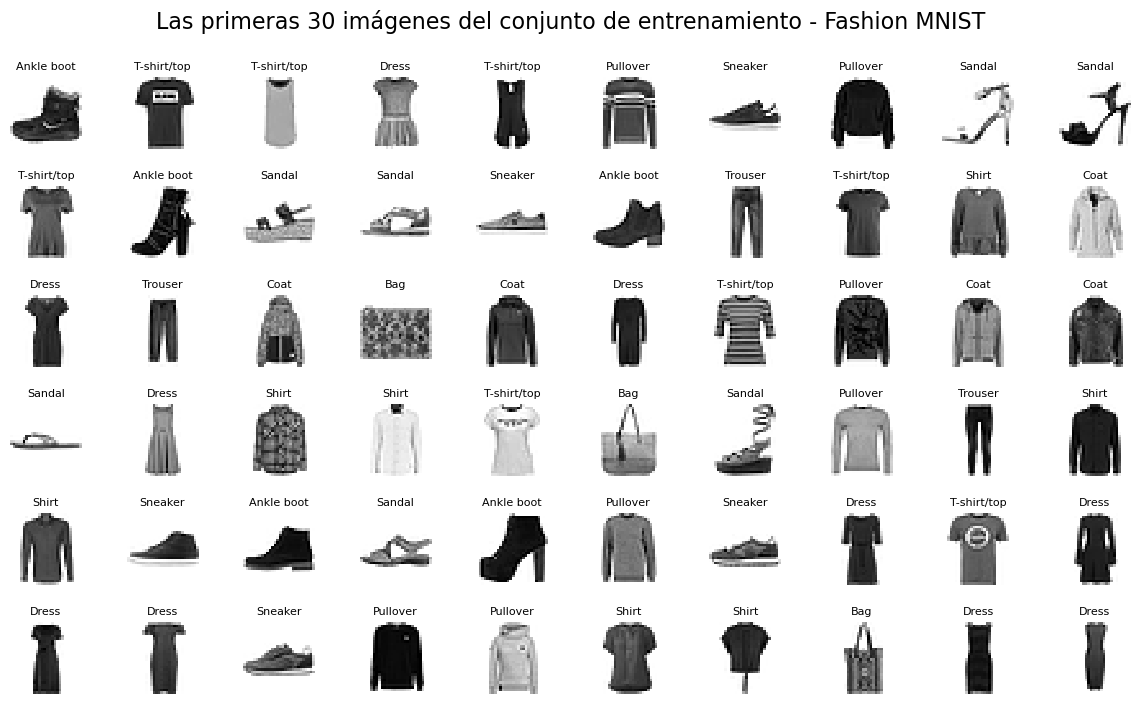

In [68]:
mostrar_guardar_imagenes(
    n_rows=6,  # Número de filas en la cuadrícula
    n_cols=10,  # Número de columnas en la cuadrícula
    x_train=x_train,  # Datos de las imágenes a mostrar
    y_train=  [class_names[i] for i in np.argmax(y_train, axis=1)]  ,  # Convierte etiquetas one-hot a números enteros para los títulos
    nombre_guardar="30_ejemplos_xtrain_FashionMNIST",  # Nombre del archivo donde se guardará la figura
    titulo="Las primeras 30 imágenes del conjunto de entrenamiento - Fashion MNIST"  # Título general de la figura
)

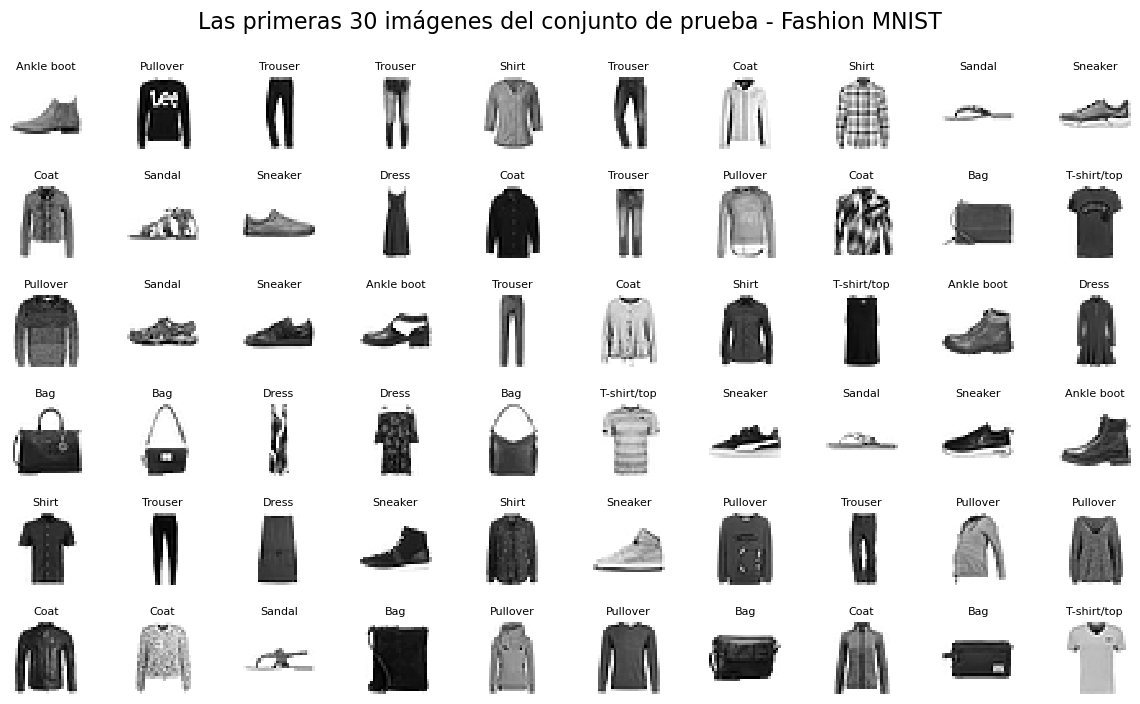

In [70]:
mostrar_guardar_imagenes(
    n_rows=6,  # Número de filas en la cuadrícula
    n_cols=10,  # Número de columnas en la cuadrícula
    x_train=x_test,  # Datos de las imágenes del conjunto de prueba a mostrar
    y_train= [class_names[i] for i in np.argmax(y_test, axis=1)] ,  # Convierte etiquetas one-hot a números enteros para los títulos
    nombre_guardar="30_ejemplos_xtest_FashionMNIST",  # Nombre del archivo donde se guardará la figura
    titulo="Las primeras 30 imágenes del conjunto de prueba - Fashion MNIST"  # Título general de la figura
)

## Modelo

In [72]:
model = keras.Sequential(
    [  # Modelo secuencial: las capas se ejecutan una tras otra en orden
        keras.Input(shape=input_shape),  # Define la forma de entrada (alto, ancho, canales)

        # Primera capa convolucional:
        # Aplica 32 filtros de tamaño 3x3 para extraer características básicas (bordes, texturas)
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

        # Capa de pooling:
        # Reduce la dimensión espacial (alto y ancho) a la mitad (2x2)
        # Ayuda a disminuir el costo computacional y evitar sobreajuste
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Segunda capa convolucional:
        # Aumenta a 64 filtros para capturar características más complejas
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),

        # Segunda capa de pooling:
        # Nuevamente reduce dimensiones espaciales
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Aplana los datos:
        # Convierte la matriz 2D en un vector 1D para conectarlo con capas densas
        layers.Flatten(),

        # Dropout:
        # Apaga aleatoriamente el 50% de las neuronas durante entrenamiento
        # Ayuda a prevenir el sobreajuste (overfitting)
        layers.Dropout(0.5),

        # Capa densa final:
        # Tiene tantas neuronas como clases (num_classes)
        # Usa softmax para obtener probabilidades de clasificación
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Muestra un resumen de la arquitectura del modelo, incluyendo capas y parámetros
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (None, 1600)             

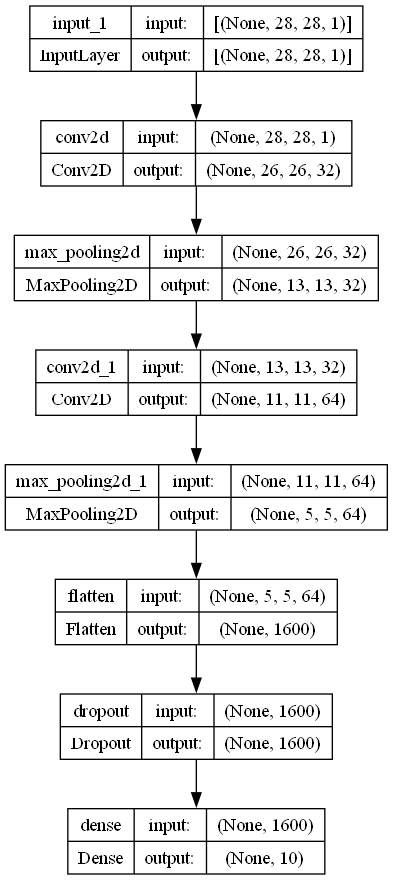

In [74]:
keras.utils.plot_model(model,  f"{IMAGES_PATH}/Model_Fashion_MNIST.png", show_shapes=True)

**Explicación del modelo CNN**

1. **Capa 1: Conv2D (32 filtros 3x3, ReLU)**  
    - Entrada: `(28, 28, 1)`  
    - Salida: `(26, 26, 32)` porque la fórmula de convolución sin padding es:  
        $W_{out} = W_{in} - K + 1$  , $H_{out} = H_{in} - K + 1$, así que $28 - 3 + 1 = 26$  
    - Parámetros: `(3*3*1 + 1)*32 = 320` (el +1 es el bias)

2. **Capa 2: MaxPooling2D (2x2)**  
    - Reduce la dimensión espacial a la mitad: `(26, 26, 32)` → `(13, 13, 32)`  
    - No tiene parámetros entrenables


3. **Capa 3: Conv2D (64 filtros 3x3, ReLU)**  
    - Entrada: `(13, 13, 32)`  
    - Salida: `(11, 11, 64)` porque `13 - 3 + 1 = 11`  
    - Parámetros: `(3*3*32 + 1)*64 = 18496`

4. **Capa 4: MaxPooling2D (2x2)**  
    - Reduce dimensión: `(11, 11, 64)` → `(5, 5, 64)` (redondeo hacia abajo)  
    - Parámetros: 0

5. **Capa 5: Flatten**  
    - Convierte `(5, 5, 64)` en vector 1D de tamaño `1600` (`5*5*64`)  
    - No tiene parámetros entrenables.


6. **Capa 6: Dropout (0.5)**  
    - Desactiva aleatoriamente 50% de las neuronas durante entrenamiento  
    - Salida: `(1600)`  
    - No tiene parámetros entrenables

7. **Capa 8: Dense final (num_classes, softmax)**   
    - Entrada: `1600`  
    - Salida: `10`  
    - Parámetros: `(1600*10 + 10) = 16,010`


**Resumen de formas y parámetros:**

| Capa | Salida (H, W, C) / Neuronas | Parámetros | Comentario |
|------|-----------------------------|------------|------------|
| Conv2D 32 | 26x26x32 | 320 | Extrae 32 mapas de características |
| MaxPool | 13x13x32 | 0 | Reduce dimensionalidad espacial |
| Conv2D 64 | 11x11x64 | 18,496 | Extrae 64 mapas de características más complejos |
| MaxPool | 5x5x64 | 0 | Reduce dimensionalidad nuevamente |
| Flatten | 1600 | 0 | Convierte a vector 1D |
| Dropout | 1600 | 0 | Evita sobreajuste |
| Dense 10 | 10 | 16,010 | Clasificación final con softmax |

Este resumen explica cómo la imagen se va transformando capa por capa, cómo cambian las dimensiones y cómo se calculan los parámetros entrenables.

En el entrenamiento de redes neuronales, no se procesan todas las imágenes de una sola vez, ya que esto requeriría demasiada memoria.

- Los datos se dividen en **batch sizes (tamaños de lote)**:
    - Esto evita que la memoria RAM se sature.
    - Es importante verificar cuántos batches puede manejar la computadora en la que se está ejecutando el entrenamiento.

El número de batches por época se calcula con la fórmula:

$$
\text{Número de batches por época} = \left\lceil \frac{\text{Número total de muestras}}{\text{Tamaño del batch}} \right\rceil
$$

**Donde:**  
- $\text{Número total de muestras}$: cantidad de datos de entrenamiento  
- $\text{Tamaño del batch (batch\_size)}$: número de muestras que se procesan antes de actualizar los pesos  
- $\lceil \cdot \rceil$: redondeo hacia arriba, para incluir el último batch aunque tenga menos muestras


In [83]:
# Definición de hiperparámetros
batch_size = 32  # Número de muestras que se procesan antes de actualizar los pesos del modelo
epochs = 15       # Número de veces que el modelo recorrerá todo el conjunto de entrenamiento

In [85]:
num_batches = math.ceil(x_train.shape[0] / batch_size)

print(f"""Número de batches por época = [{x_train.shape[0]} (No. total de muestras)/ {batch_size } (Tamaño del batch)] 
                            = [{x_train.shape[0] / batch_size}] = {num_batches} """)


Número de batches por época = [60000 (No. total de muestras)/ 32 (Tamaño del batch)] 
                            = [1875.0] = 1875 


In [87]:
# Compilación del modelo
model.compile(
    loss="categorical_crossentropy",  # Función de pérdida para clasificación multiclase
    optimizer="adam",                  # Optimizador Adam que ajusta automáticamente el learning rate
    metrics=["accuracy"]               # Métrica que se monitorea durante entrenamiento
)


In [89]:
# Entrenamiento del modelo con el dataset Fashion MNIST
history = model.fit(
    x_train, y_train,  
    # x_train: imágenes de ropa en escala de grises (28x28 píxeles)
    # y_train: etiquetas (0–9) que representan categorías como camiseta, zapato, bolso, etc.

    batch_size=batch_size,  
    # batch_size: número de imágenes procesadas antes de actualizar el modelo
    # Ejemplo: 32 o 64 es común para este dataset

    epochs=epochs,  
    # epochs: número de veces que el modelo verá las ~60,000 imágenes de entrenamiento
    # En Fashion MNIST, típicamente entre 5 y 20 épocas funciona bien

    validation_split=0.1  
    # validation_split: usa el 10% de las imágenes de entrenamiento (~6,000)
    # para validar el rendimiento durante el entrenamiento
    # Permite detectar sobreajuste (overfitting)
)

Epoch 1/15


1688/1688 [==============================] - 50s 27ms/step - loss: 0.5554 - accuracy: 0.7993 - val_loss: 0.3739 - val_accuracy: 0.8660
Epoch 2/15
1688/1688 [==============================] - 43s 25ms/step - loss: 0.3959 - accuracy: 0.8578 - val_loss: 0.3542 - val_accuracy: 0.8697
Epoch 3/15
1688/1688 [==============================] - 45s 27ms/step - loss: 0.3543 - accuracy: 0.8730 - val_loss: 0.3080 - val_accuracy: 0.8892
Epoch 4/15
1688/1688 [==============================] - 41s 24ms/step - loss: 0.3291 - accuracy: 0.8816 - val_loss: 0.3086 - val_accuracy: 0.8852
Epoch 5/15
1688/1688 [==============================] - 45s 27ms/step - loss: 0.3117 - accuracy: 0.8851 - val_loss: 0.2811 - val_accuracy: 0.8975
Epoch 6/15
1688/1688 [==============================] - 45s 26ms/step - loss: 0.2972 - accuracy: 0.8923 - val_loss: 0.2747 - val_accuracy: 0.8993
Epoch 7/15
1688/1688 [==============================] - 43s 25ms/step - loss: 0.2907 - accuracy: 0.8934 - val_loss: 0.2623

In [91]:
history.params

{'verbose': 1, 'epochs': 15, 'steps': 1688}

In [93]:
# history.epoch es una lista que contiene los índices de las épocas completadas
print(history.epoch) #Cada número representa una época completa, es decir, una pasada completa por todo el conjunto de entrenamiento

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


- La pérdida (loss) de entrenamiento disminuyó lo cual es buena señal.
- El acurracy de entrenamiento es ligeramente menor que el de validaciónivo.

In [95]:
# Convertimos el historial en DataFrame
df = pd.DataFrame(history.history)
df

,loss,accuracy,val_loss,val_accuracy
0,0.555443,0.799278,0.373944,0.866000
1,0.395920,0.857796,0.354188,0.869667
2,0.354297,0.872963,0.307997,0.889167
3,0.329101,0.881593,0.308586,0.885167
4,0.311696,0.885093,0.281126,0.897500
5,0.297207,0.892296,0.274720,0.899333
6,0.290678,0.893407,0.262287,0.905333
7,0.278339,0.898852,0.264923,0.902833
8,0.273394,0.900185,0.267998,0.902667
9,0.268306,0.902259,0.253959,0.907000


In [97]:
len(df)

15

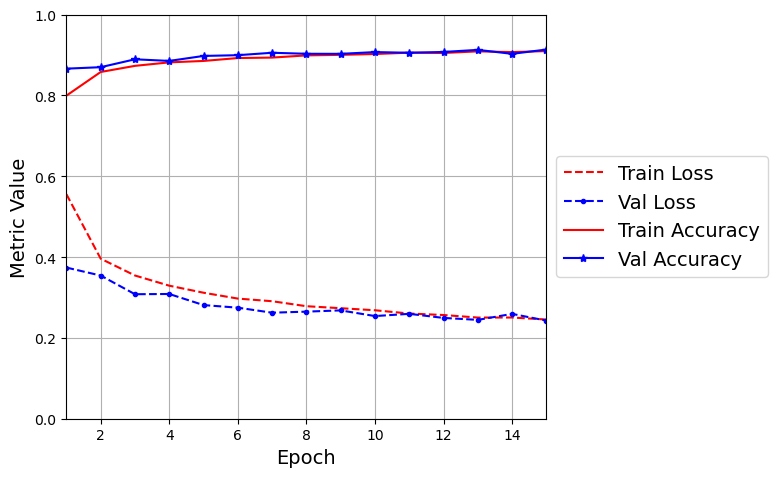

In [99]:
plot_learning_curves_clasificacion(history, "Fashion_MNIST_Model_learning_curves.png")

**NOTA:**

La **GPU T4** es mejor para redes neuronales en Colab porque:

1. **Es más rápida:** Tiene núcleos especiales (Tensor Cores) que hacen que las operaciones de redes neuronales sean mucho más rápidas.
2. **Tiene más memoria:** Permite entrenar modelos más grandes sin quedarse sin espacio.
3. **Es eficiente:** Consume menos energía y funciona bien en sesiones largas.
4. **Está optimizada para deep learning:** Librerías como TensorFlow o PyTorch la aprovechan automáticamente.

En comparación, otras GPUs antiguas como la K80 son más lentas, tienen menos memoria y no tienen esos núcleos especiales.

En pocas palabras: **T4 = más rápido, más grande, más eficiente para redes neuronales**.



In [101]:
# Evaluamos el modelo en el conjunto de prueba (datos nunca vistos)
# Devuelve la pérdida y la métrica de desempeño (accuracy en este caso)
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"""
Test loss: {test_loss:.4f}
Test accuracy: {test_accuracy:.4f}
""")

313/313 [==============================] - 2s 8ms/step - loss: 0.2573 - accuracy: 0.9085

Test loss: 0.2573
Test accuracy: 0.9085

